In [1]:
#xander bergman
#10/1

import numpy as np
import matplotlib.pyplot as plt
import glob
from scipy.special import factorial
from astropy.io import fits

def count_conversion(measured_counts):
    return (measured_counts/16) + 1

array_size = [3522, 4656]

bias_images = sorted(glob.glob(r"C:\Users\xande\ASTR362\JULESANDXANDERPICSSSS\BiasImages\*.fit"))
twilight_flats = sorted(glob.glob(r"C:\Users\xande\ASTR362\JULESANDXANDERPICSSSS\TwilightFlats\*.fit"))
darks_15s = sorted(glob.glob(r"C:\Users\xande\ASTR362\JULESANDXANDERPICSSSS\Darks\15s\*.fit"))
darks_30s = sorted(glob.glob(r"C:\Users\xande\ASTR362\JULESANDXANDERPICSSSS\Darks\30s\*.fit"))
darks_45s = sorted(glob.glob(r"C:\Users\xande\ASTR362\JULESANDXANDERPICSSSS\Darks\45s\*.fit"))

alioth_images = sorted(glob.glob(r"C:\Users\xande\ASTR362\JULESANDXANDERPICSSSS\Alioth\*.fit"))
grumium_images = sorted(glob.glob(r"C:\Users\xande\ASTR362\JULESANDXANDERPICSSSS\Grumium\*.fit"))
sadalsuud_images = sorted(glob.glob(r"C:\Users\xande\ASTR362\JULESANDXANDERPICSSSS\Sadalsuud\*.fit"))

Number of files found: 20
Shape of image_stack: (20, 3522, 4656)


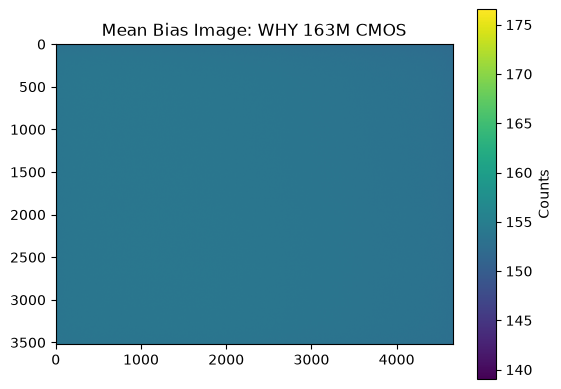

Medain of Mean Bias Image: 153.7


In [2]:
#Extract bias data and calculate average/median
bias_data_list = []
for file in bias_images:
    with fits.open(file) as foo:
        raw_data = foo[0].data
        real_data = count_conversion(raw_data)
        bias_data_list.append(real_data)
bias_stack = np.array(bias_data_list)

print(f"Number of files found: {len(bias_images)}")
print(f"Shape of image_stack: {bias_stack.shape}")

mean_bias = np.mean(bias_stack, axis=0)
plt.imshow(mean_bias)
plt.colorbar(label="Counts")
plt.title("Mean Bias Image: WHY 163M CMOS")
plt.show()

median_bias = np.median(mean_bias)
print(f"Medain of Mean Bias Image: {median_bias}")

Number of files found: 10
Shape of image_stack: (10, 3522, 4656)


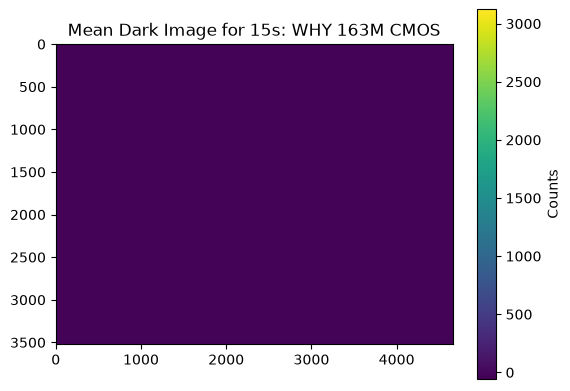

Number of files found: 10
Shape of image_stack: (10, 3522, 4656)


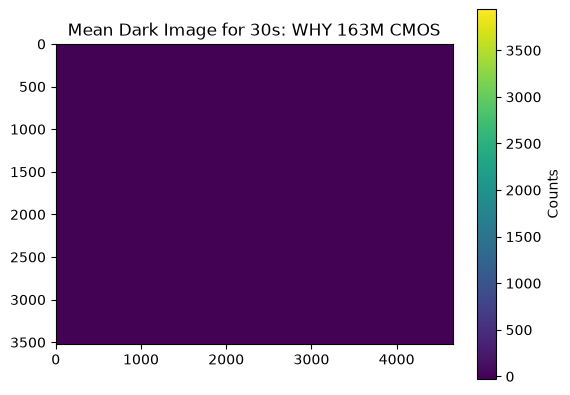

Number of files found: 10
Shape of image_stack: (10, 3522, 4656)


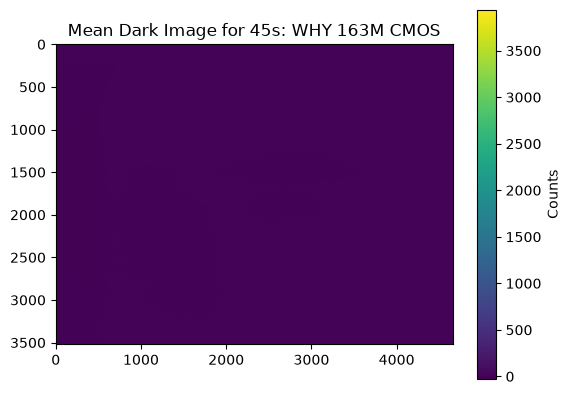

In [3]:
#Extract dark data and find averages

#------15s-------
darks_15s_list = []
for file in darks_15s:
    with fits.open(file) as foo:
        raw_data = foo[0].data
        real_data = count_conversion(raw_data)
        darks_15s_list.append(real_data)
darks_15s_stack = np.array(darks_15s_list)
darks_15s_stack -= mean_bias

print(f"Number of files found: {len(darks_15s)}")
print(f"Shape of image_stack: {darks_15s_stack.shape}")

mean_dark_15s = np.mean(darks_15s_stack, axis=0)
plt.imshow(mean_dark_15s)
plt.colorbar(label="Counts")
plt.title("Mean Dark Image for 15s: WHY 163M CMOS")
plt.show()

#------30s-------
darks_30s_list = []
for file in darks_30s:
    with fits.open(file) as foo:
        raw_data = foo[0].data
        real_data = count_conversion(raw_data)
        darks_30s_list.append(real_data)
darks_30s_stack = np.array(darks_30s_list)
darks_30s_stack -= mean_bias

print(f"Number of files found: {len(darks_30s)}")
print(f"Shape of image_stack: {darks_30s_stack.shape}")

mean_dark_30s = np.mean(darks_30s_stack, axis=0)
plt.imshow(mean_dark_30s)
plt.colorbar(label="Counts")
plt.title("Mean Dark Image for 30s: WHY 163M CMOS")
plt.show()

#------45s-------
darks_45s_list = []
for file in darks_45s:
    with fits.open(file) as foo:
        raw_data = foo[0].data
        real_data = count_conversion(raw_data)
        darks_45s_list.append(real_data)
darks_45s_stack = np.array(darks_45s_list)
darks_45s_stack -= mean_bias

print(f"Number of files found: {len(darks_45s)}")
print(f"Shape of image_stack: {darks_45s_stack.shape}")

mean_dark_45s = np.mean(darks_45s_stack, axis=0)
plt.imshow(mean_dark_45s)
plt.colorbar(label="Counts")
plt.title("Mean Dark Image for 45s: WHY 163M CMOS")
plt.show()

Number of flats used: 25
Shape of twilight_stack: (25, 3522, 4656)


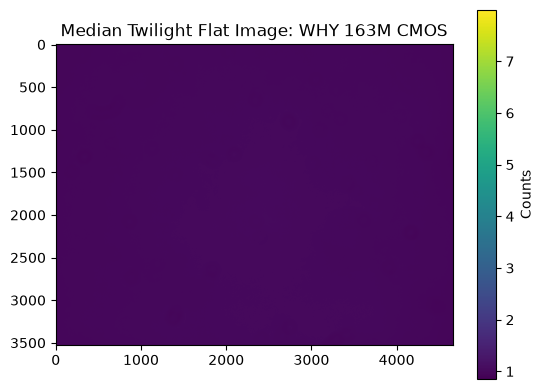

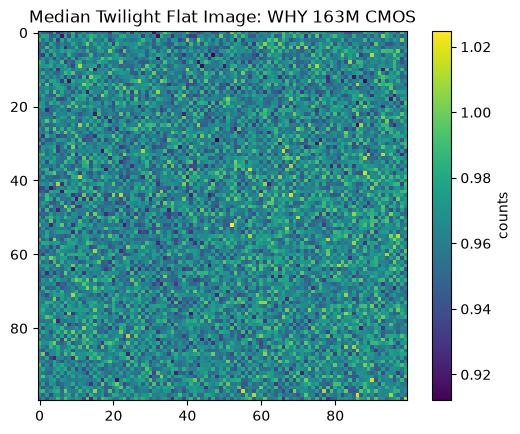

In [4]:
#Extract twilight flat data and fin normalized median
twilight_data_list = []
file_num = 0
for file in twilight_flats:
    if file_num % 4 == 0:
        with fits.open(file) as foo:
            raw_data = foo[0].data
            real_data = count_conversion(raw_data)
            bias_subtracted_flat = real_data - mean_bias
            median = np.median(bias_subtracted_flat)
            normalized_flat = bias_subtracted_flat / median
            twilight_data_list.append(normalized_flat)
            file_num += 1
    else:
        file_num += 1
twilight_stack = np.array(twilight_data_list)

print(f"Number of flats used: {len(twilight_stack)}")
print(f"Shape of twilight_stack: {twilight_stack.shape}")

median_flat = np.median(twilight_stack, axis=0)
plt.imshow(median_flat)
plt.colorbar(label="Counts")
plt.title("Median Twilight Flat Image: WHY 163M CMOS")
plt.show()

plt.imshow(median_flat[0:100,0:100])
plt.colorbar(label="counts")
plt.title("Median Twilight Flat Image: WHY 163M CMOS")
plt.savefig("bias_image.png")

Text(0.5, 1.0, 'Histogram of Bias Difference Imaging')

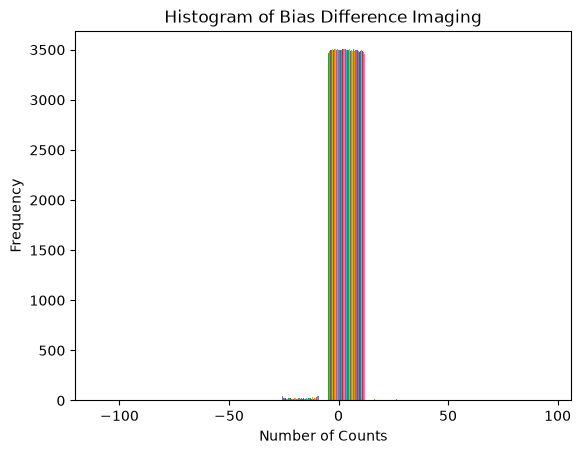

In [8]:
#Calculate random error using difference imaging
sample_bias1 = bias_stack[0]
sample_bias2 = bias_stack[1]

bias_diff = sample_bias1 - sample_bias2
read_noise = bias_diff / np.sqrt(2)

plt.hist(bias_diff)
plt.xlabel("Number of Counts")
plt.ylabel("Frequency")
plt.title("Histogram of Bias Difference Imaging")

Text(0.5, 1.0, 'Histogram of Bias Difference Imaging (Flattened)')

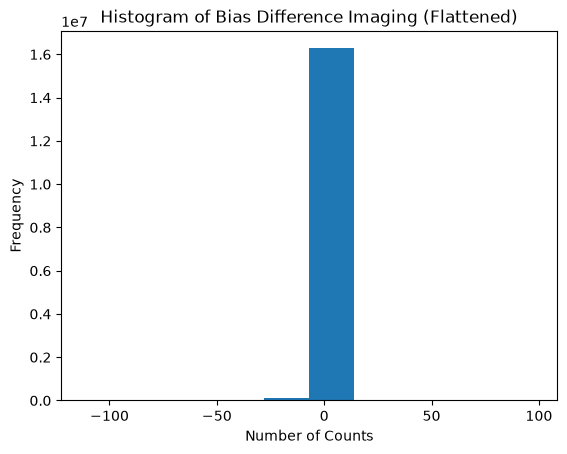

In [9]:
bias_diff_flat = bias_diff.flatten()
plt.hist(bias_diff_flat)
plt.xlabel("Number of Counts")
plt.ylabel("Frequency")
plt.title("Histogram of Bias Difference Imaging (Flattened)")

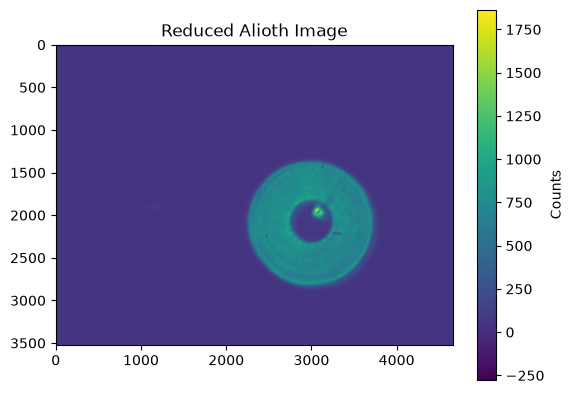

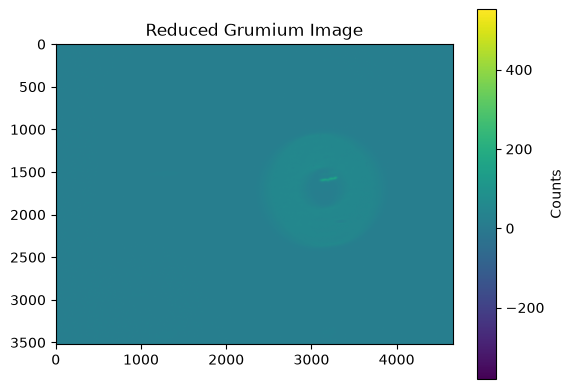

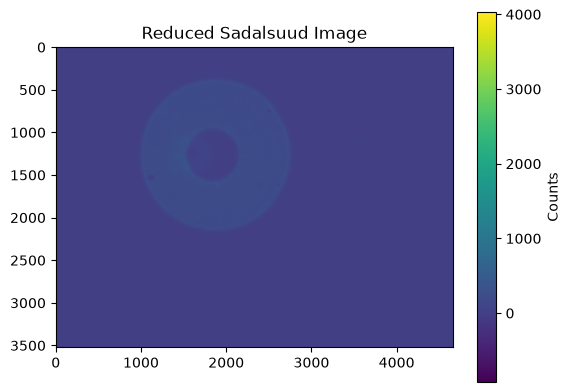

In [6]:
#Science Images!

alioth_image = fits.open(alioth_images[0])
alioth_data = np.array(alioth_image[0].data)
alioth_data_c = count_conversion(alioth_data)
alioth_image = alioth_data_c - mean_bias

grumium_image = fits.open(grumium_images[6])
grumium_data = np.array(grumium_image[0].data)
grumium_data_c = count_conversion(grumium_data)
grumium_image = grumium_data_c - mean_bias

sadalsuud_image = fits.open(sadalsuud_images[0])
sadalsuud_data = np.array(sadalsuud_image[0].data)
sadalsuud_data_c = count_conversion(sadalsuud_data)
sadalsuud_image = sadalsuud_data_c - mean_bias

alioth_reduced = (alioth_image - mean_dark_15s) / median_flat
grumium_reduced = (grumium_image - mean_dark_45s) / median_flat
sadalsuud_reduced = (sadalsuud_image - mean_dark_30s) / median_flat

plt.imshow(alioth_reduced)
plt.colorbar(label="Counts")
plt.title("Reduced Alioth Image")
plt.show()

plt.imshow(grumium_reduced)
plt.colorbar(label="Counts")
plt.title("Reduced Grumium Image")
plt.show()

plt.imshow(sadalsuud_reduced)
plt.colorbar(label="Counts")
plt.title("Reduced Sadalsuud Image")
plt.show()